Satır sayısı: 541909
Sütun sayısı: 8

Sütun isimleri:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Veri tipleri:
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

Eksik değer sayısı:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
Tarih sütunları: ['InvoiceDate']

Tarih aralığı:
2010-12-01 08:26:00 → 2011-12-09 12:50:00
Toplam Gelir: 9747747.93
Toplam Sipariş Sayısı: 25900
Ortalama Sipariş Değeri (AOV): 376.36
Yeni Müşteri Oranı (%): 30.03
Toplam iade sayısı: 9288
Toplam iade geliri: -896812.49
  InvoiceNo  IsReturn
0    536365     False
1    536365     False
2    536365     False
3    536365     False
4    536365     False
5    536365    

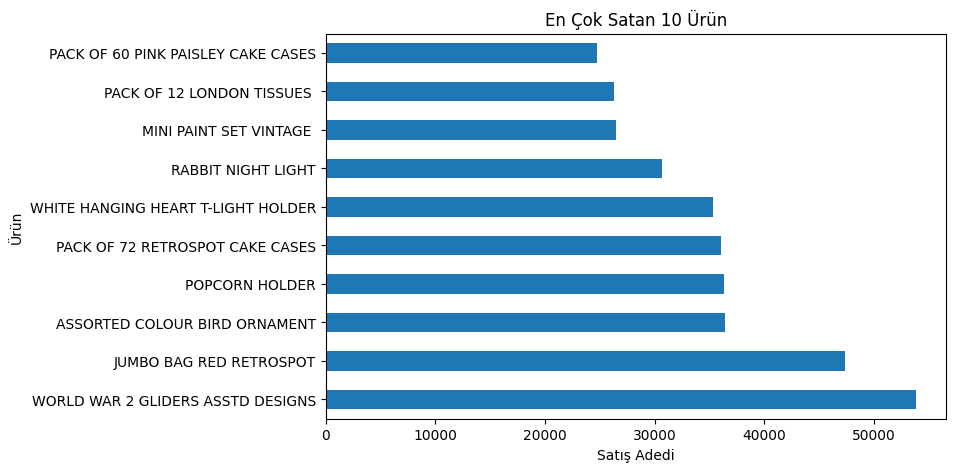

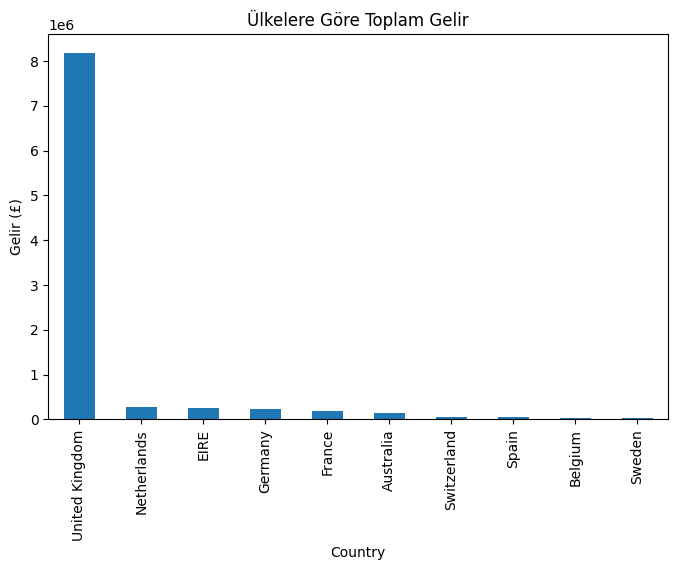

/tmp/ipykernel_47/3996641576.py:133: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_revenue = df.resample("M", on="InvoiceDate")["Revenue"].sum()


Aylık Gelirler:
InvoiceDate
2010-12-31     748957.020
2011-01-31     560000.260
2011-02-28     498062.650
2011-03-31     683267.080
2011-04-30     493207.121
2011-05-31     723333.510
2011-06-30     691123.120
2011-07-31     681300.111
2011-08-31     682680.510
2011-09-30    1019687.622
2011-10-31    1070704.670
2011-11-30    1461756.250
2011-12-31     433668.010
Freq: ME, Name: Revenue, dtype: float64
          InvoiceDate InvoiceYearMonth
0 2010-12-01 08:26:00          2010-12
1 2010-12-01 08:26:00          2010-12
2 2010-12-01 08:26:00          2010-12
3 2010-12-01 08:26:00          2010-12
4 2010-12-01 08:26:00          2010-12
5 2010-12-01 08:26:00          2010-12
6 2010-12-01 08:26:00          2010-12
7 2010-12-01 08:28:00          2010-12
8 2010-12-01 08:28:00          2010-12
9 2010-12-01 08:34:00          2010-12
          InvoiceDate  InvoiceDayOfWeek
0 2010-12-01 08:26:00                 2
1 2010-12-01 08:26:00                 2
2 2010-12-01 08:26:00                 2
3 201

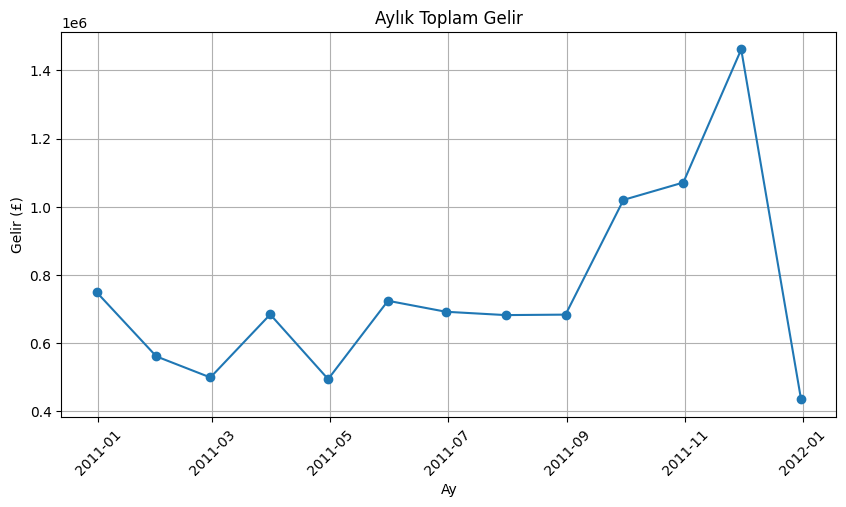

In [14]:
#Kütüphaneleri içe aktar
import pandas as pd

df = pd.read_csv("/kaggle/input/ecommerce-data/data.csv", encoding="ISO-8859-1")

#İlk 5 satıra bakalım
df.head()

#Boyut ve sütun bilgisi
print("Satır sayısı:", df.shape[0])
print("Sütun sayısı:", df.shape[1])
print("\nSütun isimleri:")
print(df.columns.tolist())

#Veri tiplerini incele
print("\nVeri tipleri:")
print(df.dtypes)

#Eksik değer sayıları
print("\nEksik değer sayısı:")
print(df.isnull().sum())

# Tarih sütunlarını bulalım
date_cols = [c for c in df.columns if "date" in c.lower() or "time" in c.lower()]
print("Tarih sütunları:", date_cols)

# Tarih aralığına bakalım
if date_cols:
    df[date_cols[0]] = pd.to_datetime(df[date_cols[0]], errors='coerce')
    print("\nTarih aralığı:")
    print(df[date_cols[0]].min(), "→", df[date_cols[0]].max())
    
# Sayısal sütunlara genel bakış
df.describe()

# Hatalı satır var mı kontrol edelim
df["InvoiceDate"].isna().sum()
df['InvoiceDate'].dtype

# Her satır için gelir (Quantity * UnitPrice)
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

# Toplam gelir
total_revenue = df["TotalPrice"].sum()
print("Toplam Gelir:", round(total_revenue, 2))
#Toplam Gelir: 9747747.93

# Toplam sipariş sayısı (iade dahil tüm faturalar)
total_orders = df['InvoiceNo'].nunique()
print("Toplam Sipariş Sayısı:", total_orders)

# Ortalama sipariş değeri
average_order_value = total_revenue / total_orders
print("Ortalama Sipariş Değeri (AOV):", round(average_order_value, 2))

# Her müşteri kaç fatura kesmiş
customer_orders = df.groupby('CustomerID')['InvoiceNo'].nunique()

# Sadece 1 sipariş verenler
new_customers = customer_orders[customer_orders == 1].count()

# Yeni müşteri oranı
new_customer_ratio = new_customers / customer_orders.count() * 100
print("Yeni Müşteri Oranı (%):", round(new_customer_ratio, 2))

# İade olan işlemleri filtrele
#İade faturaları genellikle InvoiceNo içinde “C” harfiyle başlar.
#Bunları ayıralım

returns = df[df["InvoiceNo"].astype(str).str.startswith("C")]

print("Toplam iade sayısı:", returns.shape[0])
print("Toplam iade geliri:", round(returns["TotalPrice"].sum(), 2))

#Toplam iade sayısı: 9288
#Toplam iade geliri: -896812.49

# IsReturn: InvoiceNo "C" ile başlıyorsa iade → True
df['IsReturn'] = df['InvoiceNo'].astype(str).str.startswith('C')

print(df[['InvoiceNo', 'IsReturn']].head(10))

# İade faturaları zaten IsReturn ile işaretli
return_orders = df[df['IsReturn'] == True]['InvoiceNo'].nunique()

# İade oranı
return_ratio = return_orders / total_orders * 100
print("İade Oranı (%):", round(return_ratio, 2))

# En çok satan ürünler
top_products = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
top_products

# Ülkelere göre satış dağılımı
country_sales = (
    df.groupby("Country")["TotalPrice"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
country_sales

# Görselleştirme
import matplotlib.pyplot as plt

# En çok satan ürünler
top_products.plot(kind="barh", figsize=(8,5))
plt.title("En Çok Satan 10 Ürün")
plt.xlabel("Satış Adedi")
plt.ylabel("Ürün")
plt.show()

# Ülkelere göre gelir
country_sales.plot(kind="bar", figsize=(8,5))
plt.title("Ülkelere Göre Toplam Gelir")
plt.ylabel("Gelir (£)")
plt.show()

import matplotlib.pyplot as plt

# Tarihi datetime formatına çevir
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Gelir sütunu oluştur
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

# Aylık gelir hesapla
monthly_revenue = df.resample("M", on="InvoiceDate")["Revenue"].sum()

# Sonuçları göster
print("Aylık Gelirler:")
print(monthly_revenue)

# Yıl ve ay bilgisi ekleyelim (örn. 2011-12)
df['InvoiceYearMonth'] = df['InvoiceDate'].dt.to_period('M')

print(df[['InvoiceDate', 'InvoiceYearMonth']].head(10))

# Haftanın günü (0 = Pazartesi, 6 = Pazar)
df['InvoiceDayOfWeek'] = df['InvoiceDate'].dt.dayofweek

# Kontrol
print(df[['InvoiceDate', 'InvoiceDayOfWeek']].head(10))


# Grafik
plt.figure(figsize=(10,5))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker="o")
plt.title("Aylık Toplam Gelir")
plt.xlabel("Ay")
plt.ylabel("Gelir (£)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


📊 **KPI Özet Raporu ve İş Analizi Değerlendirmesi**

Bu çalışma kapsamında, 541.909 satır ve 8 sütundan oluşan perakende satış verisi analiz edilmiştir. Veri, Aralık 2010 ile Aralık 2011 arasında gerçekleşen siparişleri temsil etmektedir. Aşağıda, yapılan analizlerden elde edilen temel bulgular ve iş açısından kritik yorumlar yer almaktadır.

🛒 1. En Çok Satan Ürünler Analizi

Yapılan satış hacmi analizine göre, en çok satılan ilk 10 ürünün büyük çoğunluğunu düşük fiyatlı ve yüksek hacimli dekoratif ürünler ve mutfak gereçleri oluşturmaktadır.

Öne çıkan bulgular:

“WORLD WAR 2 GLIDERS ASSTD DESIGNS” ürünü açık ara en çok satan ürün olmuştur.

Ürün grubunun büyük bölümü ufak hediyelik eşyalar ve düşük birim fiyatlı ürünlerden oluşmaktadır.

Bu durum şirketin satış stratejisinde yüksek hacim – düşük marj modelinin baskın olduğunu göstermektedir.

İş Yorumları:

Bu veriler, müşteri kitlesinin daha çok uygun fiyatlı, kolay satın alınabilir ürünlere yöneldiğini göstermektedir.

En çok satan ürünlerin stok planlamasında ve kampanya yönetiminde önceliklendirilmeleri gerekmektedir.

Ürün çeşitliliğinin artırılacağı bir noktada, benzer düşük fiyatlı ürün kategorileri yeni satış fırsatları yaratabilir.

🌍 2. Ülkelere Göre Gelir Analizi

Ülkeler bazında incelendiğinde açık ara en yüksek cirosu olan ülke Birleşik Krallık olmuştur. Diğer ülkelerin gelirleri İngiltere’ye kıyasla oldukça sınırlı kalmaktadır.

Dikkat çeken bulgular:

Toplam gelir yaklaşık 9,75 milyon £ seviyesindedir.

Bunun yaklaşık %80’den fazlası Birleşik Krallık kaynaklıdır.

Hollanda, İrlanda, Almanya ve Fransa ikinci grup ülkeler olmakla birlikte, pazar payları sınırlıdır.

İş Yorumları:

Şirketin gelir yapısı tek pazara aşırı bağımlı durumdadır. Bu durum operasyonel ve finansal riskleri artırmaktadır.

İngiltere dışındaki ülkelerde satışlar düşük olduğu için uluslararası genişleme stratejileri yeniden değerlendirilmelidir.

Yüksek gelirli pazarda müşteri segmentlerinin daha derin analiz edilmesi, CLV (Customer Lifetime Value) bazlı segmentasyon yapılması büyüme fırsatlarını artırabilir.

🔄 3. İade Analizi

Verisetinde toplam 9.288 adet iade işlemi tespit edilmiştir. Bu iadelerin toplam parasal karşılığı -896.812,49 £ seviyesindedir.

Öne çıkan bulgular:

İade tutarı toplam gelirin yaklaşık %9’una denk gelmektedir.

Bu seviye, sektör ortalamasının üzerinde olup operasyonel süreçlerde aksaklık olabileceğine işaret etmektedir.

En çok satılan ürünlerin bir kısmı aynı zamanda iade edilen ürünlerde de üst sıralarda yer almaktadır (düşük fiyatlı, kırılabilir/bozulabilir ürünler).

İş Yorumları:

İade sayısının yüksek olması, tedarik zinciri, paketleme kalitesi veya müşteri memnuniyeti tarafında sorunlar olduğunu düşündürmektedir.

İade nedenleri kategorize edilip kök neden analizi yapılmalıdır.

En çok iade edilen ürün ve ülke bazlı analiz yapılması, maliyetleri azaltmada kritik fayda sağlayacaktır.

🕒 4. Tarihsel Satış Davranışı

Aylık gelir grafiği ve aylık satış toplamları, yıl boyunca satışların düzenli bir artış trendi izlemediğini, ancak belirgin dönemsel dalgalanmalar olduğunu göstermektedir.

Genel Trend: Dalgalı yapı + güçlü Q4 etkisi

Yılın ilk yarısında gelirler 480K–730K £ bandında, dalgalı bir seyir izlemektedir. Bu dönem belirgin bir sezon etkisi göstermemekte, daha çok normal satış ritmini yansıtmaktadır.

Yaz aylarında (Haziran–Ağustos) satışlar nispeten stabil olup 690K–740K £ aralığında kalmıştır.

Eylül ayı itibarıyla anlamlı bir yükseliş başlamıştır.
Eylülde ~700K £ olan gelir, Ekim’de 1M £ seviyesine, Kasım’da ise 1.47M £ seviyesine çıkmıştır.

Bu artış, perakende sektöründe sık görülen Q4 sezon etkisi (Black Friday + yıl sonu alışveriş dönemleri) ile uyumludur.

Aralık Ayı Notu: Veri Eksikliği

Aralık gelirinin 434K £ olarak görünmesi satışların ani düştüğü anlamına gelmemektedir.

Veri seti Aralık ayının yalnızca ilk 9 gününü içerdiği için bu ay eksik veri göstermektedir.

Bu nedenle Aralık ayı analizlerde sezon eğilimini değerlendirmek için kullanılmamalıdır.

✔️ Sonuç:

Veri, yıl boyunca belirgin bir sezonluk dalgalanma olduğunu; özellikle Eylül–Kasım döneminde talebin hızla arttığını göstermektedir. Bu artış şirketin yılın son çeyreğinde daha yoğun bir satış performansına sahip olduğunu desteklemektedir. Aralık ayındaki düşüş ise satışlardaki zayıflıktan değil, eksik veriden kaynaklanmaktadır.

📌 Genel Değerlendirme

Yapılan analiz sonucunda şirketin operasyonları, ürün stratejisi ve pazar yapısı hakkında önemli içgörüler elde edilmiştir:

Satışlar büyük ölçüde düşük fiyatlı ürünlerden gelmektedir.

Gelirin ağırlıklı olarak Birleşik Krallık'tan gelmesi önemli bir tek pazar riski yaratmaktadır.

İade oranı yüksek olup süreç iyileştirme ihtiyacı bulunmaktadır.

Mevsimsellik etkisi güçlüdür ve yıl sonu kampanyaları kritik bir rol oynamaktadır.

Genel olarak, analiz çıktıları gelecekte yapılacak müşteri segmentasyonu, fiyat optimizasyonu, stok yönetimi ve uluslararası pazar stratejilerinin oluşturulması için sağlam bir temel sunmaktadır.

In [15]:
#RFM Analizi - MüşteriID olmayan kayıtları temizlenmesi
df_rfm = df.copy()
df_rfm = df_rfm[df_rfm["CustomerID"].notna()]
df_rfm.shape

(406829, 13)

CustomerID’si olmayan 135.080 kayıt temizlendi.

In [16]:
#Recency (Son Satın Alma) için Referans Tarihi

# InvoiceDate'i datetime formatına çevirelim.
df_rfm["InvoiceDate"] = pd.to_datetime(df_rfm["InvoiceDate"])

# Veri setindeki en son satın alma tarihi
max_date = df_rfm["InvoiceDate"].max()

max_date

Timestamp('2011-12-09 12:50:00')

Veri setindeki en son işlem 9 Aralık 2011 tarihinde yapılmış.

In [17]:
#Recency Hesaplaması (Son Alışveriş Ne Kadar Önce?)

# Referans tarih = max tarih + 1 gün
reference_date = max_date + pd.Timedelta(days=1)

# Recency hesaplama
recency_df = df_rfm.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days
}).rename(columns={"InvoiceDate": "Recency"})

recency_df.head()


,Recency
CustomerID,
12346.0,326
12347.0,2
12348.0,75
12349.0,19
12350.0,310


12347 → Recency = 2 gün → Çok yakın zamanda alışveriş yapmış

12346 → Recency = 326 gün → Neredeyse hiç gelmemiş

In [18]:
#Frequency Hesaplaması (Müşteri Kaç Kez Sipariş Vermiş?)

frequency_df = df_rfm.groupby("CustomerID").agg({
    "InvoiceNo": "nunique"
}).rename(columns={"InvoiceNo": "Frequency"})

frequency_df.head()


,Frequency
CustomerID,
12346.0,2
12347.0,7
12348.0,4
12349.0,1
12350.0,1


12347 → 7 sipariş vermiş (sadık müşteri adayı)

12349 / 12350 → Sadece 1 kez alışveriş yapmış (tek seferlik müşteri)

12346 → 2 sipariş (orta seviye)

In [19]:
#Monetary (Toplam Harcama)
# TotalPrice = Quantity * UnitPrice

df_rfm["TotalPrice"] = df_rfm["Quantity"] * df_rfm["UnitPrice"]

monetary_df = df_rfm.groupby("CustomerID").agg({
    "TotalPrice": "sum"
}).rename(columns={"TotalPrice": "Monetary"})

monetary_df.head()


,Monetary
CustomerID,
12346.0,0.00
12347.0,4310.00
12348.0,1797.24
12349.0,1757.55
12350.0,334.40


* 12347 → **£4310** harcamış → Çok yüksek değerli müşteri

* 12346 → **£0.00** → Bu müşteri muhtemelen tüm siparişleri iade etmiş

* 12350 → **£334** → Orta düşük harcama

* 12348 ve 12349 → ~**£1800** → Değerli segment adayları

In [20]:
#R, F ve M tablolarını birleştirelim

rfm = recency_df.join(frequency_df).join(monetary_df)
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,2,0.00
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


**Recency (R)**

* En yakın zamanda alışveriş yapan → 5

* Uzun süredir gelmeyen → 1

**Frequency (F)**

* En sık sipariş veren → 5

* En az sipariş veren → 1

**Monetary (M)**

* En fazla para harcayan → 5

* En az harcayan → 1


R_score: Ne kadar yakın zamanda geldi?

F_score: Ne kadar sık geldi?

M_score: Ne kadar harcama yaptı?

In [21]:
#RFM Skorlarını Hesaplayalım

# Recency: düşük recency → yüksek skor
rfm['R_score'] = pd.qcut(rfm['Recency'].rank(method='first'), 5, labels=[5,4,3,2,1])

# Frequency: yüksek frequency → yüksek skor
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first', ascending=False), 5, labels=[1,2,3,4,5])

# Monetary: yüksek harcama → yüksek skor
rfm['M_score'] = pd.qcut(rfm['Monetary'].rank(method='first', ascending=False), 5, labels=[1,2,3,4,5])

rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

def segment_map(row):
    score = row

    if score.startswith('5'):
        return 'Champions'
    if score.startswith('4'):
        return 'Loyal Customers'
    if score.startswith('3'):
        return 'Potential Loyalist'
    if score.startswith('2'):
        return 'Needs Attention'
    return 'At Risk / Lost'

rfm['Segment'] = rfm['RFM_score'].apply(segment_map)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Segment
CustomerID,,,,,,,,
12346.0,326,2,0.00,1,3,5,135,At Risk / Lost
12347.0,2,7,4310.00,5,1,1,511,Champions
12348.0,75,4,1797.24,2,2,2,222,Needs Attention
12349.0,19,1,1757.55,4,4,2,442,Loyal Customers
12350.0,310,1,334.40,1,4,4,144,At Risk / Lost


In [22]:
rfm['Segment'].value_counts()

Segment
At Risk / Lost        875
Champions             875
Needs Attention       874
Loyal Customers       874
Potential Loyalist    874
Name: count, dtype: int64

In [23]:
# Her CustomerID için en sık geçtiği Country değerini bulma
country_df = df_rfm.groupby('CustomerID')['Country'].agg(lambda x: x.mode()[0]).to_frame()

# RFM tablosuna Country bilgisini ekleyelim
rfm = rfm.join(country_df)

# İlk 5 satırı kontrol edelim
print(rfm.head())

            Recency  Frequency  Monetary R_score F_score M_score RFM_score  \
CustomerID                                                                   
12346.0         326          2      0.00       1       3       5       135   
12347.0           2          7   4310.00       5       1       1       511   
12348.0          75          4   1797.24       2       2       2       222   
12349.0          19          1   1757.55       4       4       2       442   
12350.0         310          1    334.40       1       4       4       144   

                    Segment         Country  
CustomerID                                   
12346.0      At Risk / Lost  United Kingdom  
12347.0           Champions         Iceland  
12348.0     Needs Attention         Finland  
12349.0     Loyal Customers           Italy  
12350.0      At Risk / Lost          Norway  


In [24]:
# Sadece Birleşik Krallık dışındaki müşterileri filtrele
non_uk_rfm = rfm[rfm['Country'] != 'United Kingdom']

# Ülkelere göre toplam Monetary (Gelir) hesapla
country_monetary = non_uk_rfm.groupby('Country')['Monetary'].sum().sort_values(ascending=False).head(5)

print("İngiltere Dışı En Yüksek Gelire Sahip İlk 5 Ülke:")
print(country_monetary)

İngiltere Dışı En Yüksek Gelire Sahip İlk 5 Ülke:
Country
Netherlands    284661.54
EIRE           250285.22
Germany        221698.21
France         196712.84
Australia      138467.41
Name: Monetary, dtype: float64


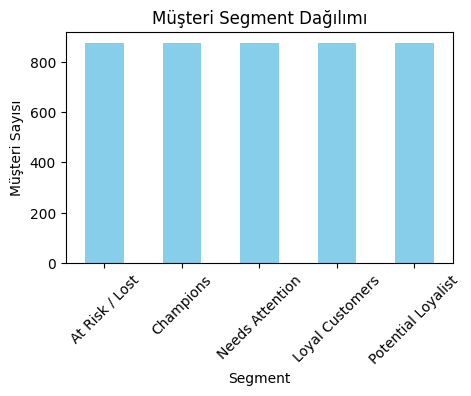

In [25]:
import matplotlib.pyplot as plt

# Segment dağılımını say
segment_counts = rfm['Segment'].value_counts()

# Grafik
plt.figure(figsize=(5,3))
segment_counts.plot(kind='bar', color='skyblue')
plt.title("Müşteri Segment Dağılımı")
plt.xlabel("Segment")
plt.ylabel("Müşteri Sayısı")
plt.xticks(rotation=45)
plt.show()

**1)Champions (875 Müşteri)**

En yüksek değer yaratan müşteri grubu. Hem yakın zamanda alışveriş yapmış hem de yüksek frekans ve harcama düzeyine sahip premium kullanıcılar.

*Veri Detayları*

* En güncel alışveriş yapan grup

* En yüksek sepet ortalaması

* Marka bağlılığı çok güçlü

*Stratejik Önemi*

Gelirin büyük bir kısmını oluşturur. Bu grubun kaybı finansal risk yaratır.

*Önerilen Aksiyonlar*

* VIP / premium müşteri programları

* Özel kampanyalar ve erken erişim

* Kişiselleştirilmiş müşteri hizmeti

- Sadakat avantajlarının artırılması

**2) Loyal Customers (874 Müşteri)**

Markayla uzun dönemli ilişki geliştirmiş, düzenli alışveriş yapan sadık müşteri kitlesi.

*Veri Detayları*

* Yüksek sipariş sıklığı

* Ortalama üzerinde harcama

* Tekrar alışveriş olasılığı çok yüksek

*Stratejik Önemi*

* Gelir sürdürülebilirliğini sağlar. Sadakatten premium seviyeye geçebilir.

*Öneriler*

* Sadakat programı geliştirmeleri

* “Referans ile müşteri kazan” kampanyaları

* Davranışa göre kişiselleştirilmiş ürün önerileri

**3) Potential Loyalist (874 Müşteri)**

Yeni kazanılmış veya sadık müşteriye dönüşme potansiyeli yüksek grup.

*Veri Detayları*

* Recency iyi → yakın zamanda alışveriş yapmış

* Harcama ve sıklık orta düzey

* Tekrar alışveriş tetiklenebilir

*Stratejik Önemi*

* Doğru temas noktaları ile uzun dönemli sadık müşteriye dönüşebilir.

*Öneriler*

* Hoş geldin serileri (e-mail / push)

* İlk alışveriş sonrası teşekkür + kişisel kupon

* Teslimat ve ürün deneyimini iyileştirerek memnuniyet artırma

**4) Needs Attention (874 Müşteri)**

Zaman zaman alışveriş yapan ancak son dönemde markadan uzaklaşma eğilimi gösteren müşteriler.

*Veri Detayları*

* Recency yüksek → uzun süredir aktif değil

* Orta seviye harcama ve frekans

* Kayıp riski artmaya başlamış

*Stratejik Önemi*

* Uygun müdahale ile tekrar aktif hale getirilebilir.

* Önerilen Aksiyonlar

* Geri kazanım e-mailleri

* Bu segmente özel indirim ve kampanyalar

* Stoka dönme, fiyat indirimi ve kampanya bildirimleri

**5) At Risk / Lost (875 Müşteri)**

Uzun süredir alışveriş yapmayan veya tamamen kaybedilmiş müşteriler. Bazıları yüksek iade oranı nedeniyle net harcaması sıfır olan kullanıcılar olabilir.

*Veri Detayları*

* Çok uzun süredir işlem yok

* Harcama düşük veya sıfıra yakın

* İade kaynaklı değer kaybı görülebilir

**Stratejik Önemi**

* Düşük dönüş potansiyeli olan, maliyeti yüksek müşteri grubudur.

*Öneriler*

* Yeniden kazanım kampanyaları (email + SMS birlikte)

* Kaybetme nedenine yönelik analiz: teslimat, iade, kalite, fiyat

* Etkileşimsiz müşterilerin sessiz listeye alınması (CRM maliyet optimizasyonu)

In [27]:
#Odak Segmentlerin Belirlenmesi
#ilk 5 ülkeyi filtreleyip, bu ülkelerdeki en değerli (Champions) ve en riskli (At Risk / Lost) müşteri segmentlerinin sayısını bulalım.

rfm = rfm.reset_index()

# Odaklanılacak ülkeler listesi
top_countries = ['Netherlands', 'EIRE', 'Germany', 'France', 'Australia']

# RFM tablosunu sadece bu ülkelere göre filtrele
focus_rfm = rfm[rfm['Country'].isin(top_countries)]

# Seçilen ülkelerdeki segment dağılımını göster
segment_distribution = focus_rfm.groupby(['Country', 'Segment'])['CustomerID'].count().unstack(fill_value=0)

print("Odak Ülkelerde Müşteri Segment Dağılımı:")
print(segment_distribution)

Odak Ülkelerde Müşteri Segment Dağılımı:
Segment      At Risk / Lost  Champions  Loyal Customers  Needs Attention  \
Country                                                                    
Australia                 1          0                2                5   
EIRE                      0          2                0                1   
France                   17         27               19               12   
Germany                  16         20               29               17   
Netherlands               3          2                2                0   

Segment      Potential Loyalist  
Country                          
Australia                     1  
EIRE                          0  
France                       12  
Germany                      13  
Netherlands                   2  


In [28]:
# 1. Sadece "Champions" segmentini filtrele
champions_df = rfm[rfm['Segment'] == 'Champions'].copy()

# 2. Her bir Champions müşterisi için Ortalama Sipariş Değeri (AOV) hesapla
# AOV = Monetary / Frequency
champions_df['AOV'] = champions_df['Monetary'] / champions_df['Frequency']

# 3. Tüm Champions müşterilerinin medyan (ortanca) AOV değerini bul
median_aov = champions_df['AOV'].median()

print(f"Champions Müşterilerinin Medyan Ortalama Sipariş Değeri (AOV): £{median_aov:.2f}")

# İlk birkaç satırı kontrol edelim
print("\nChampions Müşterileri AOV Örnekleri:")
print(champions_df[['Monetary', 'Frequency', 'AOV']].head())

Champions Müşterilerinin Medyan Ortalama Sipariş Değeri (AOV): £257.72

Champions Müşterileri AOV Örnekleri:
    Monetary  Frequency          AOV
1    4310.00          7   615.714286
11   1168.06          2   584.030000
12   6245.53          6  1040.921667
15   5154.58         13   396.506154
17   1313.10          4   328.275000
